총 344077 개의 데이터 포인트를 읽었습니다.
에피소드 수: 1000
혼동 행렬이 /home/jewoo/Desktop/SUMO_RL-main_PER_n-step/logs/ConfusionMatrix/sklearn_confusion_matrix.png에 저장되었습니다.
완료!


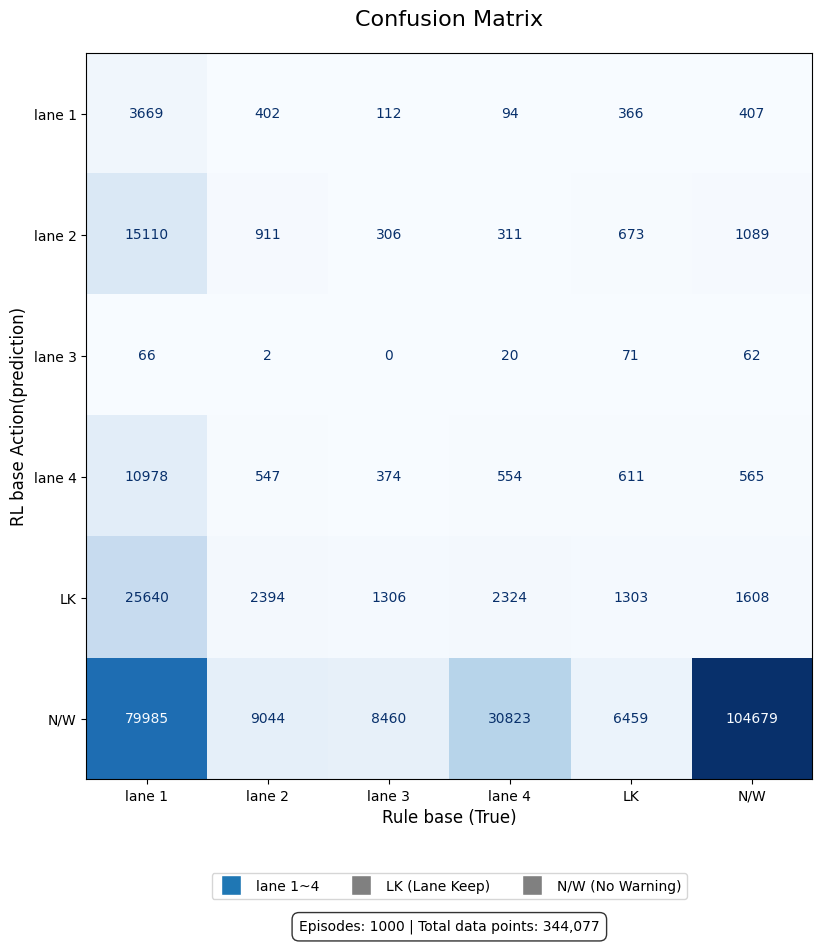

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def combine_episode_data(directory_path):
    """
    지정된 디렉토리에서 모든 에피소드 CSV 파일을 합치는 함수
    
    Parameters:
    directory_path: CSV 파일이 있는 디렉토리 경로
    
    Returns:
    combined_df: 합쳐진 데이터프레임
    """
    # 디렉토리에서 모든 CSV 파일 찾기
    csv_files = glob.glob(os.path.join(directory_path, "Episode*.csv"))
    
    # 데이터프레임 리스트
    df_list = []
    
    # 각 파일 읽기 및 리스트에 추가
    for file in csv_files:
        try:
            df = pd.read_csv(file)
            # 에피소드 번호 추가 (파일 이름에서 추출)
            episode = os.path.basename(file).replace("Episode", "").replace(".csv", "")
            df['episode'] = episode
            df_list.append(df)
        except Exception as e:
            print(f"파일 {file} 읽기 오류: {e}")
    
    # 모든 데이터프레임 합치기
    if df_list:
        combined_df = pd.concat(df_list, ignore_index=True)
        return combined_df
    else:
        print("처리할 CSV 파일이 없습니다.")
        return None

def convert_rule_to_label(value):
    """
    Rule base 값을 레이블로 변환하는 함수
    
    Parameters:
    value: 변환할 값
    
    Returns:
    label: 변환된 레이블
    """
    if value == 1:
        return "lane 1"
    elif value == 2:
        return "lane 2"
    elif value == 3:
        return "lane 3"
    elif value == 4:
        return "lane 4"
    elif value == 0:
        return "LK"  # 수정됨: N/A -> LK
    elif value == 5:
        return "N/W"  # 변경 없음: 이미 N/W
    else:
        return "N/A"  # 기본값

def convert_rl_to_label(value):
    """
    RL base 값을 레이블로 변환하는 함수
    
    Parameters:
    value: 변환할 값
    
    Returns:
    label: 변환된 레이블
    """
    if value == 1:
        return "lane 1"
    elif value == 2:
        return "lane 2"
    elif value == 3:
        return "lane 3"
    elif value == 4:
        return "lane 4"
    elif value == 0:
        return "LK"  # 변경 없음: 이미 LK
    elif value == 5:
        return "N/W"  # 수정됨: N/A -> N/W
    else:
        return "N/A"  # 기본값

def create_sklearn_confusion_matrix(data_df, save_path=None):
    """
    Sklearn을 사용하여 혼동 행렬 생성
    
    Parameters:
    data_df: 입력 데이터프레임 ('rule'과 'rl' 열 포함)
    save_path: 이미지 저장 경로 (선택 사항)
    
    Returns:
    fig: 생성된 그림 객체
    """
    # 레이블 변환
    data_df['rule_label'] = data_df['rule'].apply(convert_rule_to_label)
    data_df['rl_label'] = data_df['rl'].apply(convert_rl_to_label)
    
    # 레이블 정의 수정
    labels = ["lane 1", "lane 2", "lane 3", "lane 4", "LK", "N/W"]  # 수정됨: "N/A", "LK:N/W" -> "LK", "N/W"
    
    # sklearn의 confusion_matrix 사용 (레이블 매핑 수정)
    cm = confusion_matrix(
        y_true=data_df['rule_label'],  # 수정됨: 변환 제거 (이미 레이블이 올바르게 설정됨)
        y_pred=data_df['rl_label'],    # 수정됨: 변환 제거 (이미 레이블이 올바르게 설정됨)
        labels=labels
    )
    
    # 그림 크기 설정 - 더 큰 여백을 위해 높이 증가
    fig, ax = plt.subplots(figsize=(10, 9))
    
    # ConfusionMatrixDisplay 사용
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )
    
    # 커스텀 포맷 설정
    disp.plot(
        cmap=plt.cm.Blues,
        ax=ax,
        xticks_rotation=0,
        values_format='d',
        colorbar=False
    )
    
    # 제목 추가
    plt.title('Confusion Matrix', fontsize=16, pad=20)
    
    # Y축 레이블 추가
    plt.ylabel('RL base Action(prediction)', fontsize=12)
    plt.xlabel('Rule base (True)', fontsize=12)
    
    # 레전드 추가 - 레이블 설명 수정
    legend_elements = [
        plt.Line2D([0], [0], marker='s', color='w', label='lane 1~4',
                 markerfacecolor='#1f77b4', markersize=15),
        plt.Line2D([0], [0], marker='s', color='w', label='LK (Lane Keep)',  # 수정됨
                 markerfacecolor='gray', markersize=15),
        plt.Line2D([0], [0], marker='s', color='w', label='N/W (No Warning)',  # 수정됨
                 markerfacecolor='gray', markersize=15)
    ]
    
    plt.legend(handles=legend_elements, loc='upper center', 
             bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=True)
    
    # 여백 추가
    plt.subplots_adjust(bottom=0.25)
    
    # 에피소드 및 데이터 정보 추가
    total_data_points = len(data_df)
    info_text = f"Episodes: {data_df['episode'].nunique()} | Total data points: {total_data_points:,}"
    plt.figtext(0.5, -0.04, info_text, ha='center', fontsize=10, 
               bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
    
    plt.tight_layout()
    
    # 저장 또는 표시
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"혼동 행렬이 {save_path}에 저장되었습니다.")
    else:
        plt.show()
    
    return fig

def main():
    # 디렉토리 경로 설정 - 실제 경로로 변경 필요
    directory_path = "/home/jewoo/Desktop/SUMO_RL-main_PER_n-step/logs/ConfusionMatrix"  # 예: "/home/user/SUMO_RL-main/logs/sumo_origin_simple_env/ConfusionMatrix"
    
    # 에피소드 데이터 합치기
    combined_data = combine_episode_data(directory_path)
    
    if combined_data is not None:
        # 몇 개의 데이터를 읽었는지 확인
        print(f"총 {len(combined_data)} 개의 데이터 포인트를 읽었습니다.")
        print(f"에피소드 수: {combined_data['episode'].nunique()}")
        
        # 기본 sklearn 혼동 행렬 생성 및 저장
        output_path1 = os.path.join(directory_path, "sklearn_confusion_matrix.png")
        fig1 = create_sklearn_confusion_matrix(combined_data, save_path=output_path1)
        
        print("완료!")

if __name__ == "__main__":
    main()